<a href="https://colab.research.google.com/github/chandiki/Notion-SentimentAnalysis/blob/main/1C_Artikel_BPJSI_PBI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Dependencies

In [1]:
import nltk
from nltk.tokenize import sent_tokenize
nltk.download('punkt')
from sklearn.feature_extraction.text import TfidfVectorizer

import pandas as pd

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


# Define Document

**Sumber artikel:**  
[Sistem Baru Kemensos Picu Penonaktifan BPJS PBI Warga Malang, Akses Kesehatan Terhambat
](https://www.acehground.com/nasional/sistem-baru-kemensos-picu-penonaktifan-bpjs-pbi-warga-malang-akses-kesehatan-terhambat/#google_vignette)

In [2]:
sentence2 = """
Sejumlah warga di Desa Donowarih, Kecamatan Karangploso, Kabupaten Malang, Jawa Timur, kini menghadapi kendala serius setelah kepesertaan BPJS Kesehatan Penerima Bantuan Iuran (PBI) mereka dinonaktifkan secara mendadak. Penonaktifan ini baru diketahui saat mereka membutuhkan perawatan medis, termasuk pasien dengan penyakit kronis yang memerlukan penanganan berkelanjutan di rumah sakit.

Permasalahan ini, menurut pemerintah desa setempat, berakar pada perubahan sistem pendataan bantuan sosial di Kementerian Sosial. Sistem Data Terpadu Kesejahteraan Sosial (DTKS) telah bertransformasi menjadi Data Terpadu Sosial Ekonomi Nasional (DTSEN), yang berdampak langsung pada status kepesertaan PBI.

Sekretaris Desa Donowarih, Ary Widy Hartono, menjelaskan bahwa perubahan ini menyebabkan klasifikasi warga ke dalam desil 1 hingga 10 berdasarkan pendataan Kemensos dari berbagai sumber. “Data warga itu sifatnya dinamis. Sekarang diklasifikasikan ke desil 1-10 berdasarkan pendataan Kemensos dari berbagai sumber, sehingga posisi desil warga bisa berubah,” kata Ary saat dihubungi pada Minggu (8/2).

Ary menambahkan, penonaktifan terjadi ketika warga yang sebelumnya tergolong dalam desil 1-5 bergeser ke desil 6-10. Namun, kendala utama muncul karena pemerintah desa tidak menerima pembaruan data tersebut secara berkala. “Yang jadi persoalan, desa tidak menerima data perubahan itu secara berkala. Akibatnya, warga baru tahu BPJS-nya nonaktif ketika sudah sakit dan butuh layanan rumah sakit,” ujarnya.

AcehGround mencatat bahwa setidaknya ada tiga warga yang telah mengadu ke pemerintah desa karena tidak dapat mengakses layanan kesehatan akibat status BPJS PBI mereka yang dinonaktifkan. Bagi warga yang tidak sedang sakit, perubahan status ini seringkali tidak disadari. Namun, bagi mereka yang memerlukan perawatan rutin, kondisi ini menjadi sangat krusial. “Dari tiga warga yang BPJS PBI mereka dinonaktifkan itu, satu pasien harus cuci darah secara rutin. Ada juga yang membutuhkan kontrol lanjutan ke rumah sakit,” jelas Ary.

Meskipun seluruh warga yang melapor telah kembali mendapatkan kepesertaan aktif dan bisa mengakses layanan kesehatan, Ary mengakui keterbatasan pemerintah desa dalam memantau data secara menyeluruh. “Kami di desa tidak bisa memastikan berapa jumlah warga yang sebetulnya masih masuk desil 1-5, tetapi kepesertaan PBI-nya sudah dinonaktifkan. Padahal ketika PBI dihentikan, baik yang ditanggung APBN maupun APBD, statusnya langsung nonaktif total,” paparnya.

Minimnya keterbukaan data dan pemahaman administrasi di tingkat desa memperparah persoalan, mendorong sebagian warga untuk beralih ke BPJS mandiri, meskipun kemudian kesulitan dalam membayar iuran. Selain itu, Ary juga menyoroti carut-marut data kependudukan yang lebih luas. “Masih ada lebih dari 200 warga yang sudah meninggal tetapi tercatat dalam data. Ini berdampak langsung pada BPJS dan bantuan sosial,” kata Ary.

Situasi ini menggarisbawahi pentingnya pembaruan data yang akurat dan transparan untuk memastikan bantuan sosial, termasuk akses kesehatan, tepat sasaran. Ary berharap pemerintah pusat segera melakukan pembaruan data kependudukan secara menyeluruh dan membuka akses keterbukaan data yang lebih baik bagi pemerintah desa. “Kalau data kependudukan rapi dan terbuka, bantuan akan lebih tepat sasaran, warga tidak lagi kesulitan saat sakit, dan potensi penyimpangan bisa ditekan,” pungkasnya.
"""

# Text Preprocessing

In [3]:
import nltk
from nltk.tokenize import sent_tokenize

# Download the 'punkt_tab' data
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [4]:
# Sentence tokenization
sent_token2 = sent_tokenize(sentence2)
print(sent_token2)

['\nSejumlah warga di Desa Donowarih, Kecamatan Karangploso, Kabupaten Malang, Jawa Timur, kini menghadapi kendala serius setelah kepesertaan BPJS Kesehatan Penerima Bantuan Iuran (PBI) mereka dinonaktifkan secara mendadak.', 'Penonaktifan ini baru diketahui saat mereka membutuhkan perawatan medis, termasuk pasien dengan penyakit kronis yang memerlukan penanganan berkelanjutan di rumah sakit.', 'Permasalahan ini, menurut pemerintah desa setempat, berakar pada perubahan sistem pendataan bantuan sosial di Kementerian Sosial.', 'Sistem Data Terpadu Kesejahteraan Sosial (DTKS) telah bertransformasi menjadi Data Terpadu Sosial Ekonomi Nasional (DTSEN), yang berdampak langsung pada status kepesertaan PBI.', 'Sekretaris Desa Donowarih, Ary Widy Hartono, menjelaskan bahwa perubahan ini menyebabkan klasifikasi warga ke dalam desil 1 hingga 10 berdasarkan pendataan Kemensos dari berbagai sumber.', '“Data warga itu sifatnya dinamis.', 'Sekarang diklasifikasikan ke desil 1-10 berdasarkan pendataan

In [5]:
!pip install Sastrawi

In [6]:
import nltk
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Download the 'punkt' data if you haven't already
try:
    nltk.data.find('tokenizers/punkt/PY3/english.pickle')
except nltk.downloader.DownloadError:
    nltk.download('punkt')

sentence2 = """
Sejumlah warga di Desa Donowarih, Kecamatan Karangploso, Kabupaten Malang, Jawa Timur, kini menghadapi kendala serius setelah kepesertaan BPJS Kesehatan Penerima Bantuan Iuran (PBI) mereka dinonaktifkan secara mendadak. Penonaktifan ini baru diketahui saat mereka membutuhkan perawatan medis, termasuk pasien dengan penyakit kronis yang memerlukan penanganan berkelanjutan di rumah sakit.

Permasalahan ini, menurut pemerintah desa setempat, berakar pada perubahan sistem pendataan bantuan sosial di Kementerian Sosial. Sistem Data Terpadu Kesejahteraan Sosial (DTKS) telah bertransformasi menjadi Data Terpadu Sosial Ekonomi Nasional (DTSEN), yang berdampak langsung pada status kepesertaan PBI.

Sekretaris Desa Donowarih, Ary Widy Hartono, menjelaskan bahwa perubahan ini menyebabkan klasifikasi warga ke dalam desil 1 hingga 10 berdasarkan pendataan Kemensos dari berbagai sumber. “Data warga itu sifatnya dinamis. Sekarang diklasifikasikan ke desil 1-10 berdasarkan pendataan Kemensos dari berbagai sumber, sehingga posisi desil warga bisa berubah,” kata Ary saat dihubungi pada Minggu (8/2).

Ary menambahkan, penonaktifan terjadi ketika warga yang sebelumnya tergolong dalam desil 1-5 bergeser ke desil 6-10. Namun, kendala utama muncul karena pemerintah desa tidak menerima pembaruan data tersebut secara berkala. “Yang jadi persoalan, desa tidak menerima data perubahan itu secara berkala. Akibatnya, warga baru tahu BPJS-nya nonaktif ketika sudah sakit dan butuh layanan rumah sakit,” ujarnya.

AcehGround mencatat bahwa setidaknya ada tiga warga yang telah mengadu ke pemerintah desa karena tidak dapat mengakses layanan kesehatan akibat status BPJS PBI mereka yang dinonaktifkan. Bagi warga yang tidak sedang sakit, perubahan status ini seringkali tidak disadari. Namun, bagi mereka yang memerlukan perawatan rutin, kondisi ini menjadi sangat krusial. “Dari tiga warga yang BPJS PBI mereka dinonaktifkan itu, satu pasien harus cuci darah secara rutin. Ada juga yang membutuhkan kontrol lanjutan ke rumah sakit,” jelas Ary.

Meskipun seluruh warga yang melapor telah kembali mendapatkan kepesertaan aktif dan bisa mengakses layanan kesehatan, Ary mengakui keterbatasan pemerintah desa dalam memantau data secara menyeluruh. “Kami di desa tidak bisa memastikan berapa jumlah warga yang sebetulnya masih masuk desil 1-5, tetapi kepesertaan PBI-nya sudah dinonaktifkan. Padahal ketika PBI dihentikan, baik yang ditanggung APBN maupun APBD, statusnya langsung nonaktif total,” paparnya.

Minimnya keterbukaan data dan pemahaman administrasi di tingkat desa memperparah persoalan, mendorong sebagian warga untuk beralih ke BPJS mandiri, meskipun kemudian kesulitan dalam membayar iuran. Selain itu, Ary juga menyoroti carut-marut data kependudukan yang lebih luas. “Masih ada lebih dari 200 warga yang sudah meninggal tetapi tercatat dalam data. Ini berdampak langsung pada BPJS dan bantuan sosial,” kata Ary.

Situasi ini menggarisbawahi pentingnya pembaruan data yang akurat dan transparan untuk memastikan bantuan sosial, termasuk akses kesehatan, tepat sasaran. Ary berharap pemerintah pusat segera melakukan pembaruan data kependudukan secara menyeluruh dan membuka akses keterbukaan data yang lebih baik bagi pemerintah desa. “Kalau data kependudukan rapi dan terbuka, bantuan akan lebih tepat sasaran, warga tidak lagi kesulitan saat sakit, dan potensi penyimpangan bisa ditekan,” pungkasnya.
"""

# Sentence tokenization
sent_token2 = sent_tokenize(sentence2)
print("Tokenized sentences:")
for sent in sent_token2:
    print(sent)

# Initialize Indonesian StopWordRemover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Remove stop words from each sentence
cleaned_sentences = [stopword_remover.remove(sent) for sent in sent_token2]
print("\nCleaned sentences (Indonesian stop words removed):")
for clean_sent in cleaned_sentences:
    print(clean_sent)

# Training TF-IDF Vectorizer on the cleaned sentences
vectorizer = TfidfVectorizer()  # Removed stop_words='english'
features = vectorizer.fit_transform(cleaned_sentences)

print("\nTF-IDF Feature Matrix (Sparse) on cleaned sentences:")
print(features)

print("\nShape of the Feature Matrix (Number of sentences, Number of unique words after Indonesian stop word removal):")
print(features.shape)

# To see the feature names (the words in the vocabulary after Indonesian stop word removal):
feature_names = vectorizer.get_feature_names_out()
print("\nFeature Names (Words in the vocabulary after Indonesian stop word removal):")
print(feature_names)

# To see the TF-IDF values for a specific cleaned sentence (e.g., the first):
if cleaned_sentences:
    first_cleaned_sentence_tfidf = features[0].toarray()
    print("\nTF-IDF values for the first cleaned sentence:")
    print(first_cleaned_sentence_tfidf)

    import pandas as pd
    def get_tfidf_for_sentence(tfidf_matrix, sentence_index, feature_names):
        """Returns a DataFrame of TF-IDF values for a given sentence."""
        sentence_tfidf_values = tfidf_matrix[sentence_index].toarray().flatten()
        tfidf_df = pd.DataFrame({'Feature': feature_names, 'TF-IDF': sentence_tfidf_values})
        tfidf_df = tfidf_df[tfidf_df['TF-IDF'] > 0].sort_values(by='TF-IDF', ascending=False)
        return tfidf_df

    first_cleaned_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)
    print("\nTF-IDF values for the first cleaned sentence (sorted):")
    print(first_cleaned_sentence_tfidf_df)
else:
    print("\nNo cleaned sentences to process.")

Tokenized sentences:

Sejumlah warga di Desa Donowarih, Kecamatan Karangploso, Kabupaten Malang, Jawa Timur, kini menghadapi kendala serius setelah kepesertaan BPJS Kesehatan Penerima Bantuan Iuran (PBI) mereka dinonaktifkan secara mendadak.
Penonaktifan ini baru diketahui saat mereka membutuhkan perawatan medis, termasuk pasien dengan penyakit kronis yang memerlukan penanganan berkelanjutan di rumah sakit.
Permasalahan ini, menurut pemerintah desa setempat, berakar pada perubahan sistem pendataan bantuan sosial di Kementerian Sosial.
Sistem Data Terpadu Kesejahteraan Sosial (DTKS) telah bertransformasi menjadi Data Terpadu Sosial Ekonomi Nasional (DTSEN), yang berdampak langsung pada status kepesertaan PBI.
Sekretaris Desa Donowarih, Ary Widy Hartono, menjelaskan bahwa perubahan ini menyebabkan klasifikasi warga ke dalam desil 1 hingga 10 berdasarkan pendataan Kemensos dari berbagai sumber.
“Data warga itu sifatnya dinamis.
Sekarang diklasifikasikan ke desil 1-10 berdasarkan pendataan

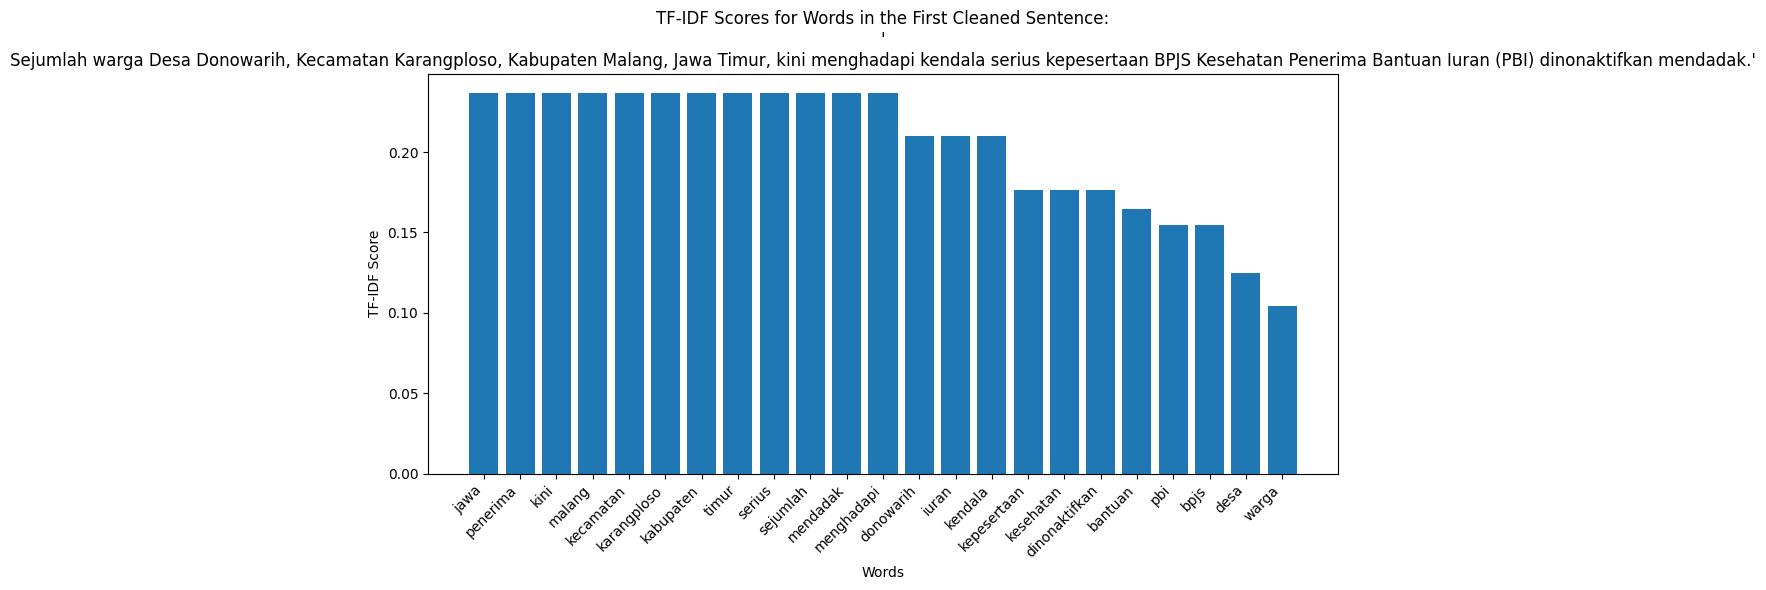

In [7]:
import nltk
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import matplotlib.pyplot as plt
import pandas as pd

# Download 'punkt' if needed
try:
    nltk.data.find('tokenizers/punkt/PY3/english.pickle')
except nltk.downloader.DownloadError:
    nltk.download('punkt')

sentence2 = """
Sejumlah warga di Desa Donowarih, Kecamatan Karangploso, Kabupaten Malang, Jawa Timur, kini menghadapi kendala serius setelah kepesertaan BPJS Kesehatan Penerima Bantuan Iuran (PBI) mereka dinonaktifkan secara mendadak. Penonaktifan ini baru diketahui saat mereka membutuhkan perawatan medis, termasuk pasien dengan penyakit kronis yang memerlukan penanganan berkelanjutan di rumah sakit.

Permasalahan ini, menurut pemerintah desa setempat, berakar pada perubahan sistem pendataan bantuan sosial di Kementerian Sosial. Sistem Data Terpadu Kesejahteraan Sosial (DTKS) telah bertransformasi menjadi Data Terpadu Sosial Ekonomi Nasional (DTSEN), yang berdampak langsung pada status kepesertaan PBI.

Sekretaris Desa Donowarih, Ary Widy Hartono, menjelaskan bahwa perubahan ini menyebabkan klasifikasi warga ke dalam desil 1 hingga 10 berdasarkan pendataan Kemensos dari berbagai sumber. “Data warga itu sifatnya dinamis. Sekarang diklasifikasikan ke desil 1-10 berdasarkan pendataan Kemensos dari berbagai sumber, sehingga posisi desil warga bisa berubah,” kata Ary saat dihubungi pada Minggu (8/2).

Ary menambahkan, penonaktifan terjadi ketika warga yang sebelumnya tergolong dalam desil 1-5 bergeser ke desil 6-10. Namun, kendala utama muncul karena pemerintah desa tidak menerima pembaruan data tersebut secara berkala. “Yang jadi persoalan, desa tidak menerima data perubahan itu secara berkala. Akibatnya, warga baru tahu BPJS-nya nonaktif ketika sudah sakit dan butuh layanan rumah sakit,” ujarnya.

AcehGround mencatat bahwa setidaknya ada tiga warga yang telah mengadu ke pemerintah desa karena tidak dapat mengakses layanan kesehatan akibat status BPJS PBI mereka yang dinonaktifkan. Bagi warga yang tidak sedang sakit, perubahan status ini seringkali tidak disadari. Namun, bagi mereka yang memerlukan perawatan rutin, kondisi ini menjadi sangat krusial. “Dari tiga warga yang BPJS PBI mereka dinonaktifkan itu, satu pasien harus cuci darah secara rutin. Ada juga yang membutuhkan kontrol lanjutan ke rumah sakit,” jelas Ary.

Meskipun seluruh warga yang melapor telah kembali mendapatkan kepesertaan aktif dan bisa mengakses layanan kesehatan, Ary mengakui keterbatasan pemerintah desa dalam memantau data secara menyeluruh. “Kami di desa tidak bisa memastikan berapa jumlah warga yang sebetulnya masih masuk desil 1-5, tetapi kepesertaan PBI-nya sudah dinonaktifkan. Padahal ketika PBI dihentikan, baik yang ditanggung APBN maupun APBD, statusnya langsung nonaktif total,” paparnya.

Minimnya keterbukaan data dan pemahaman administrasi di tingkat desa memperparah persoalan, mendorong sebagian warga untuk beralih ke BPJS mandiri, meskipun kemudian kesulitan dalam membayar iuran. Selain itu, Ary juga menyoroti carut-marut data kependudukan yang lebih luas. “Masih ada lebih dari 200 warga yang sudah meninggal tetapi tercatat dalam data. Ini berdampak langsung pada BPJS dan bantuan sosial,” kata Ary.

Situasi ini menggarisbawahi pentingnya pembaruan data yang akurat dan transparan untuk memastikan bantuan sosial, termasuk akses kesehatan, tepat sasaran. Ary berharap pemerintah pusat segera melakukan pembaruan data kependudukan secara menyeluruh dan membuka akses keterbukaan data yang lebih baik bagi pemerintah desa. “Kalau data kependudukan rapi dan terbuka, bantuan akan lebih tepat sasaran, warga tidak lagi kesulitan saat sakit, dan potensi penyimpangan bisa ditekan,” pungkasnya.
"""

# Sentence tokenization
sent_token2 = sent_tokenize(sentence2)

# Initialize Indonesian StopWordRemover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Remove stop words from each sentence
cleaned_sentences = [stopword_remover.remove(sent) for sent in sent_token2]

# Training TF-IDF Vectorizer on the cleaned sentences
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)
feature_names = vectorizer.get_feature_names_out()

# Get TF-IDF scores for the first cleaned sentence
if cleaned_sentences:
    first_cleaned_sentence = cleaned_sentences[0]
    first_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)

    # Visualize the TF-IDF scores as a histogram
    plt.figure(figsize=(10, 6))
    plt.bar(first_sentence_tfidf_df['Feature'], first_sentence_tfidf_df['TF-IDF'])
    plt.xlabel("Words")
    plt.ylabel("TF-IDF Score")
    plt.title(f"TF-IDF Scores for Words in the First Cleaned Sentence:\n'{first_cleaned_sentence}'")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No cleaned sentences to visualize.")

# Calculate Sentence Score

**List of Sentences:**
1. 
Sejumlah warga di Desa Donowarih, Kecamatan Karangploso, Kabupaten Malang, Jawa Timur, kini menghadapi kendala serius setelah kepesertaan BPJS Kesehatan Penerima Bantuan Iuran (PBI) mereka dinonaktifkan secara mendadak.
2. Penonaktifan ini baru diketahui saat mereka membutuhkan perawatan medis, termasuk pasien dengan penyakit kronis yang memerlukan penanganan berkelanjutan di rumah sakit.
3. Permasalahan ini, menurut pemerintah desa setempat, berakar pada perubahan sistem pendataan bantuan sosial di Kementerian Sosial.
4. Sistem Data Terpadu Kesejahteraan Sosial (DTKS) telah bertransformasi menjadi Data Terpadu Sosial Ekonomi Nasional (DTSEN), yang berdampak langsung pada status kepesertaan PBI.
5. Sekretaris Desa Donowarih, Ary Widy Hartono, menjelaskan bahwa perubahan ini menyebabkan klasifikasi warga ke dalam desil 1 hingga 10 berdasarkan pendataan Kemensos dari berbagai sumber.
6. “Data warga itu sifatnya dinamis.
7. Sekarang diklasifikasikan ke desil 1-1

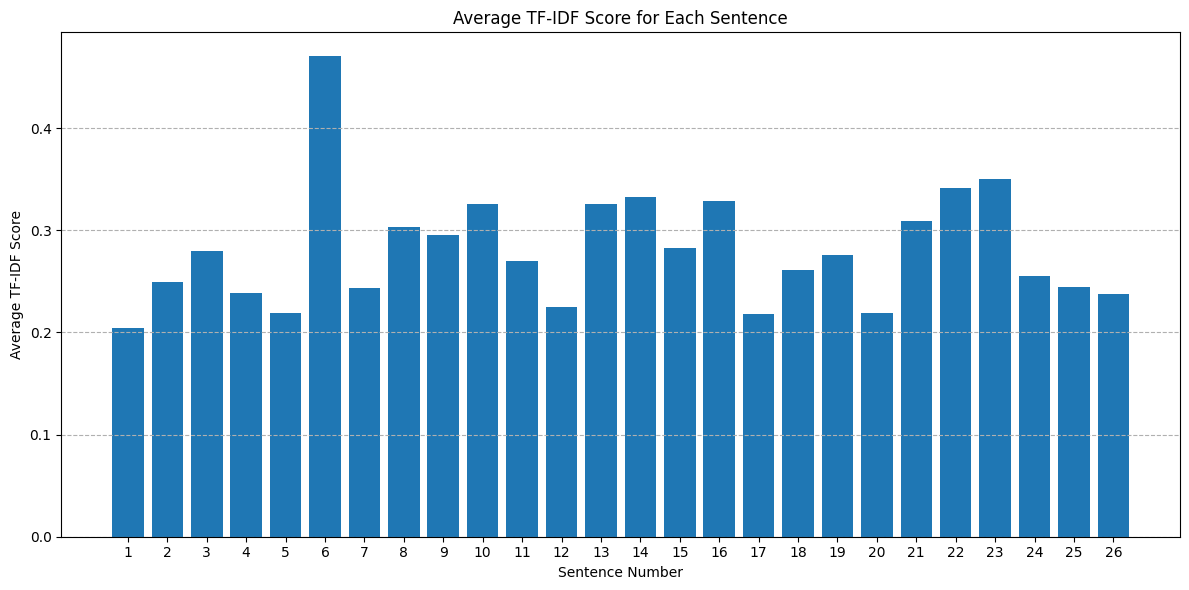


**Explanation of the Histogram :**
Imagine we've given each sentence in the news article a score based on the importance of the words it contains. This score is called the 'Average TF-IDF Score'.

The histogram above is like a bar chart that shows this score for each sentence:
- **The horizontal line (Sentence Number):** Each number on this line represents a different sentence in the article, starting from the first sentence (1) to the last.
- **The vertical bar for each sentence:** The height of each bar shows the 'Average TF-IDF Score' for that particular sentence.

**What does the height of the bar tell us?**
- **Taller bar:** A taller bar means the sentence contains words that are considered more important and unique within the entire article. These sentences likely carry more key information.
- **Shorter bar:** A shorter bar means the sentence contains words that are either less important or more common throughout the article. These sentences might be supporting details or less c

In [8]:
import nltk
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import matplotlib.pyplot as plt

# Download the 'punkt' data if needed
try:
    nltk.data.find('tokenizers/punkt/PY3/english.pickle')
except nltk.downloader.DownloadError:
    nltk.download('punkt')

sentence2 = """
Sejumlah warga di Desa Donowarih, Kecamatan Karangploso, Kabupaten Malang, Jawa Timur, kini menghadapi kendala serius setelah kepesertaan BPJS Kesehatan Penerima Bantuan Iuran (PBI) mereka dinonaktifkan secara mendadak. Penonaktifan ini baru diketahui saat mereka membutuhkan perawatan medis, termasuk pasien dengan penyakit kronis yang memerlukan penanganan berkelanjutan di rumah sakit.

Permasalahan ini, menurut pemerintah desa setempat, berakar pada perubahan sistem pendataan bantuan sosial di Kementerian Sosial. Sistem Data Terpadu Kesejahteraan Sosial (DTKS) telah bertransformasi menjadi Data Terpadu Sosial Ekonomi Nasional (DTSEN), yang berdampak langsung pada status kepesertaan PBI.

Sekretaris Desa Donowarih, Ary Widy Hartono, menjelaskan bahwa perubahan ini menyebabkan klasifikasi warga ke dalam desil 1 hingga 10 berdasarkan pendataan Kemensos dari berbagai sumber. “Data warga itu sifatnya dinamis. Sekarang diklasifikasikan ke desil 1-10 berdasarkan pendataan Kemensos dari berbagai sumber, sehingga posisi desil warga bisa berubah,” kata Ary saat dihubungi pada Minggu (8/2).

Ary menambahkan, penonaktifan terjadi ketika warga yang sebelumnya tergolong dalam desil 1-5 bergeser ke desil 6-10. Namun, kendala utama muncul karena pemerintah desa tidak menerima pembaruan data tersebut secara berkala. “Yang jadi persoalan, desa tidak menerima data perubahan itu secara berkala. Akibatnya, warga baru tahu BPJS-nya nonaktif ketika sudah sakit dan butuh layanan rumah sakit,” ujarnya.

AcehGround mencatat bahwa setidaknya ada tiga warga yang telah mengadu ke pemerintah desa karena tidak dapat mengakses layanan kesehatan akibat status BPJS PBI mereka yang dinonaktifkan. Bagi warga yang tidak sedang sakit, perubahan status ini seringkali tidak disadari. Namun, bagi mereka yang memerlukan perawatan rutin, kondisi ini menjadi sangat krusial. “Dari tiga warga yang BPJS PBI mereka dinonaktifkan itu, satu pasien harus cuci darah secara rutin. Ada juga yang membutuhkan kontrol lanjutan ke rumah sakit,” jelas Ary.

Meskipun seluruh warga yang melapor telah kembali mendapatkan kepesertaan aktif dan bisa mengakses layanan kesehatan, Ary mengakui keterbatasan pemerintah desa dalam memantau data secara menyeluruh. “Kami di desa tidak bisa memastikan berapa jumlah warga yang sebetulnya masih masuk desil 1-5, tetapi kepesertaan PBI-nya sudah dinonaktifkan. Padahal ketika PBI dihentikan, baik yang ditanggung APBN maupun APBD, statusnya langsung nonaktif total,” paparnya.

Minimnya keterbukaan data dan pemahaman administrasi di tingkat desa memperparah persoalan, mendorong sebagian warga untuk beralih ke BPJS mandiri, meskipun kemudian kesulitan dalam membayar iuran. Selain itu, Ary juga menyoroti carut-marut data kependudukan yang lebih luas. “Masih ada lebih dari 200 warga yang sudah meninggal tetapi tercatat dalam data. Ini berdampak langsung pada BPJS dan bantuan sosial,” kata Ary.

Situasi ini menggarisbawahi pentingnya pembaruan data yang akurat dan transparan untuk memastikan bantuan sosial, termasuk akses kesehatan, tepat sasaran. Ary berharap pemerintah pusat segera melakukan pembaruan data kependudukan secara menyeluruh dan membuka akses keterbukaan data yang lebih baik bagi pemerintah desa. “Kalau data kependudukan rapi dan terbuka, bantuan akan lebih tepat sasaran, warga tidak lagi kesulitan saat sakit, dan potensi penyimpangan bisa ditekan,” pungkasnya.
"""

# Sentence tokenization
sent_token2 = sent_tokenize(sentence2)

# Initialize Indonesian StopWordRemover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Remove stop words from each sentence
cleaned_sentences = [stopword_remover.remove(sent) for sent in sent_token2]

# Training TF-IDF Vectorizer on the cleaned sentences
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)

# Variable initialization
sent_index = 0
sent_scores = []

# Calculate sentence TF-IDF score and list sentences
print("**List of Sentences:**")
for i, sent in enumerate(sent_token2):
    print(f"{i + 1}. {sent}")
print("\n-------------------------")

# Calculate average TF-IDF score for each sentence
print("\n**Average TF-IDF Score for Each Sentence:**")
for i in features:
    print(f"- Sentence {sent_index + 1}")
    sent_score = i.sum()
    sent_length = len(i.data)
    print("  Sum of TF-IDF scores:", sent_score)
    print("  Number of words:", sent_length)
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    print("  Average TF-IDF score:", avg_score)
    sent_scores.append(avg_score)
    sent_index += 1
print("\n-------------------------")

print("\nList of average TF-IDF scores for each sentence:")
print(sent_scores)

# Visualize the average TF-IDF scores as a histogram
plt.figure(figsize=(12, 6))
plt.bar(range(1, len(sent_scores) + 1), sent_scores)
plt.xlabel("Sentence Number")
plt.ylabel("Average TF-IDF Score")
plt.title("Average TF-IDF Score for Each Sentence")
plt.xticks(range(1, len(sent_scores) + 1))
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

# Explanation:
print("\n**Explanation of the Histogram :**")
print("Imagine we've given each sentence in the news article a score based on the importance of the words it contains. This score is called the 'Average TF-IDF Score'.")
print("\nThe histogram above is like a bar chart that shows this score for each sentence:")
print("- **The horizontal line (Sentence Number):** Each number on this line represents a different sentence in the article, starting from the first sentence (1) to the last.")
print("- **The vertical bar for each sentence:** The height of each bar shows the 'Average TF-IDF Score' for that particular sentence.")
print("\n**What does the height of the bar tell us?**")
print("- **Taller bar:** A taller bar means the sentence contains words that are considered more important and unique within the entire article. These sentences likely carry more key information.")
print("- **Shorter bar:** A shorter bar means the sentence contains words that are either less important or more common throughout the article. These sentences might be supporting details or less central to the main topic.")
print("\nSo, by looking at this chart, you can quickly get a sense of which sentences in the article are likely to be the most informative based on the words they use.")


# Define Threshold

In [9]:
import nltk
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Download the 'punkt' data if needed
try:
    nltk.data.find('tokenizers/punkt/PY3/english.pickle')
except nltk.downloader.DownloadError:
    nltk.download('punkt')

sentence2 = """
Sejumlah warga di Desa Donowarih, Kecamatan Karangploso, Kabupaten Malang, Jawa Timur, kini menghadapi kendala serius setelah kepesertaan BPJS Kesehatan Penerima Bantuan Iuran (PBI) mereka dinonaktifkan secara mendadak. Penonaktifan ini baru diketahui saat mereka membutuhkan perawatan medis, termasuk pasien dengan penyakit kronis yang memerlukan penanganan berkelanjutan di rumah sakit.

Permasalahan ini, menurut pemerintah desa setempat, berakar pada perubahan sistem pendataan bantuan sosial di Kementerian Sosial. Sistem Data Terpadu Kesejahteraan Sosial (DTKS) telah bertransformasi menjadi Data Terpadu Sosial Ekonomi Nasional (DTSEN), yang berdampak langsung pada status kepesertaan PBI.

Sekretaris Desa Donowarih, Ary Widy Hartono, menjelaskan bahwa perubahan ini menyebabkan klasifikasi warga ke dalam desil 1 hingga 10 berdasarkan pendataan Kemensos dari berbagai sumber. “Data warga itu sifatnya dinamis. Sekarang diklasifikasikan ke desil 1-10 berdasarkan pendataan Kemensos dari berbagai sumber, sehingga posisi desil warga bisa berubah,” kata Ary saat dihubungi pada Minggu (8/2).

Ary menambahkan, penonaktifan terjadi ketika warga yang sebelumnya tergolong dalam desil 1-5 bergeser ke desil 6-10. Namun, kendala utama muncul karena pemerintah desa tidak menerima pembaruan data tersebut secara berkala. “Yang jadi persoalan, desa tidak menerima data perubahan itu secara berkala. Akibatnya, warga baru tahu BPJS-nya nonaktif ketika sudah sakit dan butuh layanan rumah sakit,” ujarnya.

AcehGround mencatat bahwa setidaknya ada tiga warga yang telah mengadu ke pemerintah desa karena tidak dapat mengakses layanan kesehatan akibat status BPJS PBI mereka yang dinonaktifkan. Bagi warga yang tidak sedang sakit, perubahan status ini seringkali tidak disadari. Namun, bagi mereka yang memerlukan perawatan rutin, kondisi ini menjadi sangat krusial. “Dari tiga warga yang BPJS PBI mereka dinonaktifkan itu, satu pasien harus cuci darah secara rutin. Ada juga yang membutuhkan kontrol lanjutan ke rumah sakit,” jelas Ary.

Meskipun seluruh warga yang melapor telah kembali mendapatkan kepesertaan aktif dan bisa mengakses layanan kesehatan, Ary mengakui keterbatasan pemerintah desa dalam memantau data secara menyeluruh. “Kami di desa tidak bisa memastikan berapa jumlah warga yang sebetulnya masih masuk desil 1-5, tetapi kepesertaan PBI-nya sudah dinonaktifkan. Padahal ketika PBI dihentikan, baik yang ditanggung APBN maupun APBD, statusnya langsung nonaktif total,” paparnya.

Minimnya keterbukaan data dan pemahaman administrasi di tingkat desa memperparah persoalan, mendorong sebagian warga untuk beralih ke BPJS mandiri, meskipun kemudian kesulitan dalam membayar iuran. Selain itu, Ary juga menyoroti carut-marut data kependudukan yang lebih luas. “Masih ada lebih dari 200 warga yang sudah meninggal tetapi tercatat dalam data. Ini berdampak langsung pada BPJS dan bantuan sosial,” kata Ary.

Situasi ini menggarisbawahi pentingnya pembaruan data yang akurat dan transparan untuk memastikan bantuan sosial, termasuk akses kesehatan, tepat sasaran. Ary berharap pemerintah pusat segera melakukan pembaruan data kependudukan secara menyeluruh dan membuka akses keterbukaan data yang lebih baik bagi pemerintah desa. “Kalau data kependudukan rapi dan terbuka, bantuan akan lebih tepat sasaran, warga tidak lagi kesulitan saat sakit, dan potensi penyimpangan bisa ditekan,” pungkasnya.
"""

# Sentence tokenization
sent_token2 = sent_tokenize(sentence2)

# Initialize Indonesian StopWordRemover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Remove stop words from each sentence
cleaned_sentences = [stopword_remover.remove(sent) for sent in sent_token2]

# Training TF-IDF Vectorizer on the cleaned sentences
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)

# Variable initialization
sent_index = 0
sent_scores = []

# Calculate sentence TF-IDF score
for i in features:
    sent_score = i.sum()
    sent_length = len(i.data)
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    sent_scores.append(avg_score)

# Calculate the average of all sentence scores (threshold)
threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0

print("Threshold (Average of Sentence Scores):", threshold)

Threshold (Average of Sentence Scores): 0.2810511781586321


In [10]:
import nltk
from nltk.tokenize import word_tokenize
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import math

# Download the 'punkt' data if needed
try:
    nltk.data.find('tokenizers/punkt/PY3/english.pickle')
except nltk.downloader.DownloadError:
    nltk.download('punkt')

# Initialize Indonesian StopWordRemover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

sentences = [
    "Sejumlah warga di Desa Donowarih Kecamatan Karangploso Kabupaten Malang menghadapi kendala setelah kepesertaan BPJS Kesehatan PBI mereka dinonaktifkan secara mendadak.",
    "Penonaktifan ini baru diketahui saat warga membutuhkan layanan kesehatan di rumah sakit.",
    "Beberapa pasien yang terdampak merupakan penderita penyakit kronis yang membutuhkan perawatan rutin.",
    "Pemerintah desa menyebut persoalan ini berkaitan dengan perubahan sistem pendataan bantuan sosial dari DTKS menjadi DTSEN.",
    "Perubahan sistem tersebut berdampak langsung pada status kepesertaan BPJS PBI masyarakat.",
    "Sekretaris Desa Donowarih Ary Widy Hartono menjelaskan bahwa warga kini diklasifikasikan ke dalam desil 1 sampai 10 berdasarkan pendataan Kemensos.",
    "Data warga bersifat dinamis sehingga posisi desil dapat berubah sewaktu-waktu.",
    "Penonaktifan BPJS terjadi ketika warga yang sebelumnya berada di desil 1 sampai 5 bergeser ke desil 6 sampai 10.",
    "Pemerintah desa tidak menerima pembaruan data secara berkala dari pusat.",
    "Akibatnya warga baru mengetahui BPJS mereka nonaktif ketika sedang sakit dan membutuhkan layanan rumah sakit.",
    "Setidaknya ada tiga warga yang telah mengadu ke pemerintah desa karena tidak dapat mengakses layanan kesehatan.",
    "Salah satu warga yang terdampak harus menjalani cuci darah secara rutin.",
    "Warga lainnya membutuhkan kontrol lanjutan ke rumah sakit.",
    "Bagi warga yang tidak sedang sakit perubahan status BPJS sering kali tidak disadari.",
    "Namun bagi pasien dengan kebutuhan perawatan rutin kondisi ini menjadi sangat krusial.",
    "Seluruh warga yang melapor kini telah kembali mendapatkan kepesertaan BPJS aktif.",
    "Mereka kembali dapat mengakses layanan kesehatan setelah status kepesertaan diperbaiki.",
    "Pemerintah desa mengaku kesulitan memantau perubahan data warga secara menyeluruh.",
    "Desa tidak dapat memastikan jumlah warga yang masih layak menerima PBI tetapi kepesertaannya sudah dinonaktifkan.",
    "Ketika status PBI dihentikan baik dari APBN maupun APBD kepesertaan BPJS langsung nonaktif total.",
    "Minimnya keterbukaan data memperparah persoalan di tingkat desa.",
    "Kurangnya pemahaman administrasi membuat sebagian warga memilih beralih ke BPJS mandiri.",
    "Sebagian warga kemudian mengalami kesulitan membayar iuran BPJS mandiri.",
    "Ary juga menyoroti persoalan data kependudukan yang belum tertata dengan baik.",
    "Masih terdapat lebih dari 200 warga yang sudah meninggal tetapi masih tercatat dalam data administrasi.",
    "Permasalahan data tersebut berdampak langsung pada BPJS dan bantuan sosial lainnya.",
    "Situasi ini menunjukkan pentingnya pembaruan data kependudukan yang akurat dan transparan.",
    "Pembaruan data diperlukan agar bantuan sosial dan layanan kesehatan tepat sasaran.",
    "Ary berharap pemerintah pusat segera memperbaiki dan memperbarui data kependudukan secara menyeluruh.",
    "Pemerintah desa juga berharap adanya keterbukaan akses data yang lebih baik dari pemerintah pusat.",
    "Data yang rapi dan terbuka diyakini dapat mengurangi kesulitan warga saat membutuhkan layanan kesehatan.",
    "Perbaikan data juga dinilai dapat menekan potensi penyimpangan bantuan sosial."
]

# Initialize a list to store cleaned sentences
all_cleaned_sentences = []
for sentence in sentences:
    cleaned_sentence = stopword_remover.remove(sentence)
    all_cleaned_sentences.append(cleaned_sentence)

# Function to calculate TF for a term in a document
def calculate_tf(term, document):
    words = word_tokenize(document.lower())
    return words.count(term) / len(words) if len(words) > 0 else 0

# Function to calculate IDF for a term across all documents
def calculate_idf(term, all_documents):
    num_documents_with_term = sum(1 for doc in all_documents if term.lower() in word_tokenize(doc.lower()))
    if num_documents_with_term > 0:
        return math.log(len(all_documents) / num_documents_with_term)
    else:
        return 0

# Calculate TF-IDF for "pbi" in each sentence
tfidf_scores = {}
for i, sentence in enumerate(sentences):
    cleaned_sentence = stopword_remover.remove(sentence)
    tf = calculate_tf("pbi", cleaned_sentence)
    idf = calculate_idf("pbi", all_cleaned_sentences)
    tfidf = tf * idf
    tfidf_scores[f"Sentence {i+1}"] = tfidf

# Print the TF-IDF scores for "pbi" in each sentence
print("TF-IDF Score for 'pbi' in each cleaned sentence:")
for sentence_num, score in tfidf_scores.items():
    print(f"{sentence_num}: {score:.4f}")

# Calculate the overall IDF for "pbi" across all cleaned sentences
overall_idf_investasi = calculate_idf("pbi", all_cleaned_sentences)
print(f"\nOverall IDF for 'pbi': {overall_idf_investasi:.4f}")

TF-IDF Score for 'pbi' in each cleaned sentence:
Sentence 1: 0.1223
Sentence 2: 0.0000
Sentence 3: 0.0000
Sentence 4: 0.0000
Sentence 5: 0.1890
Sentence 6: 0.0000
Sentence 7: 0.0000
Sentence 8: 0.0000
Sentence 9: 0.0000
Sentence 10: 0.0000
Sentence 11: 0.0000
Sentence 12: 0.0000
Sentence 13: 0.0000
Sentence 14: 0.0000
Sentence 15: 0.0000
Sentence 16: 0.0000
Sentence 17: 0.0000
Sentence 18: 0.0000
Sentence 19: 0.1733
Sentence 20: 0.1485
Sentence 21: 0.0000
Sentence 22: 0.0000
Sentence 23: 0.0000
Sentence 24: 0.0000
Sentence 25: 0.0000
Sentence 26: 0.0000
Sentence 27: 0.0000
Sentence 28: 0.0000
Sentence 29: 0.0000
Sentence 30: 0.0000
Sentence 31: 0.0000
Sentence 32: 0.0000

Overall IDF for 'pbi': 2.0794


# Get Sentences

In [11]:
import nltk
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Download the 'punkt' data if needed
try:
    nltk.data.find('tokenizers/punkt/PY3/english.pickle')
except nltk.downloader.DownloadError:
    nltk.download('punkt')

sentence2 = """
Sejumlah warga di Desa Donowarih, Kecamatan Karangploso, Kabupaten Malang, Jawa Timur, kini menghadapi kendala serius setelah kepesertaan BPJS Kesehatan Penerima Bantuan Iuran (PBI) mereka dinonaktifkan secara mendadak. Penonaktifan ini baru diketahui saat mereka membutuhkan perawatan medis, termasuk pasien dengan penyakit kronis yang memerlukan penanganan berkelanjutan di rumah sakit.

Permasalahan ini, menurut pemerintah desa setempat, berakar pada perubahan sistem pendataan bantuan sosial di Kementerian Sosial. Sistem Data Terpadu Kesejahteraan Sosial (DTKS) telah bertransformasi menjadi Data Terpadu Sosial Ekonomi Nasional (DTSEN), yang berdampak langsung pada status kepesertaan PBI.

Sekretaris Desa Donowarih, Ary Widy Hartono, menjelaskan bahwa perubahan ini menyebabkan klasifikasi warga ke dalam desil 1 hingga 10 berdasarkan pendataan Kemensos dari berbagai sumber. “Data warga itu sifatnya dinamis. Sekarang diklasifikasikan ke desil 1-10 berdasarkan pendataan Kemensos dari berbagai sumber, sehingga posisi desil warga bisa berubah,” kata Ary saat dihubungi pada Minggu (8/2).

Ary menambahkan, penonaktifan terjadi ketika warga yang sebelumnya tergolong dalam desil 1-5 bergeser ke desil 6-10. Namun, kendala utama muncul karena pemerintah desa tidak menerima pembaruan data tersebut secara berkala. “Yang jadi persoalan, desa tidak menerima data perubahan itu secara berkala. Akibatnya, warga baru tahu BPJS-nya nonaktif ketika sudah sakit dan butuh layanan rumah sakit,” ujarnya.

AcehGround mencatat bahwa setidaknya ada tiga warga yang telah mengadu ke pemerintah desa karena tidak dapat mengakses layanan kesehatan akibat status BPJS PBI mereka yang dinonaktifkan. Bagi warga yang tidak sedang sakit, perubahan status ini seringkali tidak disadari. Namun, bagi mereka yang memerlukan perawatan rutin, kondisi ini menjadi sangat krusial. “Dari tiga warga yang BPJS PBI mereka dinonaktifkan itu, satu pasien harus cuci darah secara rutin. Ada juga yang membutuhkan kontrol lanjutan ke rumah sakit,” jelas Ary.

Meskipun seluruh warga yang melapor telah kembali mendapatkan kepesertaan aktif dan bisa mengakses layanan kesehatan, Ary mengakui keterbatasan pemerintah desa dalam memantau data secara menyeluruh. “Kami di desa tidak bisa memastikan berapa jumlah warga yang sebetulnya masih masuk desil 1-5, tetapi kepesertaan PBI-nya sudah dinonaktifkan. Padahal ketika PBI dihentikan, baik yang ditanggung APBN maupun APBD, statusnya langsung nonaktif total,” paparnya.

Minimnya keterbukaan data dan pemahaman administrasi di tingkat desa memperparah persoalan, mendorong sebagian warga untuk beralih ke BPJS mandiri, meskipun kemudian kesulitan dalam membayar iuran. Selain itu, Ary juga menyoroti carut-marut data kependudukan yang lebih luas. “Masih ada lebih dari 200 warga yang sudah meninggal tetapi tercatat dalam data. Ini berdampak langsung pada BPJS dan bantuan sosial,” kata Ary.

Situasi ini menggarisbawahi pentingnya pembaruan data yang akurat dan transparan untuk memastikan bantuan sosial, termasuk akses kesehatan, tepat sasaran. Ary berharap pemerintah pusat segera melakukan pembaruan data kependudukan secara menyeluruh dan membuka akses keterbukaan data yang lebih baik bagi pemerintah desa. “Kalau data kependudukan rapi dan terbuka, bantuan akan lebih tepat sasaran, warga tidak lagi kesulitan saat sakit, dan potensi penyimpangan bisa ditekan,” pungkasnya.
"""

# Sentence tokenization (using the original sentence2)
sent_token = sent_tokenize(sentence2)

# Initialize Indonesian StopWordRemover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Remove stop words from each sentence
cleaned_sentences = [stopword_remover.remove(sent) for sent in sent_token]

# Training TF-IDF Vectorizer on the cleaned sentences
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)

# Variable initialization
sent_index = 0
sent_scores = []

# Calculate average TF-IDF score for each sentence
for i in features:
    sent_score = i.sum()
    sent_length = len(i.data)
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    sent_scores.append(avg_score)

# Calculate the average of all sentence scores (threshold)
threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0

print("Threshold (Average of Sentence Scores):", threshold)

# Final summary initialization
final_summ = ""

# Get summary sentences
print("\nSummary Sentences (above or equal to the threshold):")
for index, data in enumerate(sent_scores):
    if data >= threshold:
        final_summ = final_summ + " " + sent_token[index]
        print(f"- {sent_token[index]}")

print("\nFinal Summary:")
print(final_summ.strip())

Threshold (Average of Sentence Scores): 0.2810511781586321

Summary Sentences (above or equal to the threshold):
- “Data warga itu sifatnya dinamis.
- Ary menambahkan, penonaktifan terjadi ketika warga yang sebelumnya tergolong dalam desil 1-5 bergeser ke desil 6-10.
- Namun, kendala utama muncul karena pemerintah desa tidak menerima pembaruan data tersebut secara berkala.
- “Yang jadi persoalan, desa tidak menerima data perubahan itu secara berkala.
- Bagi warga yang tidak sedang sakit, perubahan status ini seringkali tidak disadari.
- Namun, bagi mereka yang memerlukan perawatan rutin, kondisi ini menjadi sangat krusial.
- “Dari tiga warga yang BPJS PBI mereka dinonaktifkan itu, satu pasien harus cuci darah secara rutin.
- Ada juga yang membutuhkan kontrol lanjutan ke rumah sakit,” jelas Ary.
- Selain itu, Ary juga menyoroti carut-marut data kependudukan yang lebih luas.
- “Masih ada lebih dari 200 warga yang sudah meninggal tetapi tercatat dalam data.
- Ini berdampak langsung pada B

In [12]:
import nltk
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import math

# Download the 'punkt' data if needed
try:
    nltk.data.find('tokenizers/punkt/PY3/english.pickle')
except nltk.downloader.DownloadError:
    nltk.download('punkt')

sentences = [
    "Sejumlah warga di Desa Donowarih Kecamatan Karangploso Kabupaten Malang menghadapi kendala setelah kepesertaan BPJS Kesehatan PBI mereka dinonaktifkan secara mendadak.",
    "Penonaktifan ini baru diketahui saat warga membutuhkan layanan kesehatan di rumah sakit.",
    "Beberapa pasien yang terdampak merupakan penderita penyakit kronis yang membutuhkan perawatan rutin.",
    "Pemerintah desa menyebut persoalan ini berkaitan dengan perubahan sistem pendataan bantuan sosial dari DTKS menjadi DTSEN.",
    "Perubahan sistem tersebut berdampak langsung pada status kepesertaan BPJS PBI masyarakat.",
    "Sekretaris Desa Donowarih Ary Widy Hartono menjelaskan bahwa warga kini diklasifikasikan ke dalam desil 1 sampai 10 berdasarkan pendataan Kemensos.",
    "Data warga bersifat dinamis sehingga posisi desil dapat berubah sewaktu-waktu.",
    "Penonaktifan BPJS terjadi ketika warga yang sebelumnya berada di desil 1 sampai 5 bergeser ke desil 6 sampai 10.",
    "Pemerintah desa tidak menerima pembaruan data secara berkala dari pusat.",
    "Akibatnya warga baru mengetahui BPJS mereka nonaktif ketika sedang sakit dan membutuhkan layanan rumah sakit.",
    "Setidaknya ada tiga warga yang telah mengadu ke pemerintah desa karena tidak dapat mengakses layanan kesehatan.",
    "Salah satu warga yang terdampak harus menjalani cuci darah secara rutin.",
    "Warga lainnya membutuhkan kontrol lanjutan ke rumah sakit.",
    "Bagi warga yang tidak sedang sakit perubahan status BPJS sering kali tidak disadari.",
    "Namun bagi pasien dengan kebutuhan perawatan rutin kondisi ini menjadi sangat krusial.",
    "Seluruh warga yang melapor kini telah kembali mendapatkan kepesertaan BPJS aktif.",
    "Mereka kembali dapat mengakses layanan kesehatan setelah status kepesertaan diperbaiki.",
    "Pemerintah desa mengaku kesulitan memantau perubahan data warga secara menyeluruh.",
    "Desa tidak dapat memastikan jumlah warga yang masih layak menerima PBI tetapi kepesertaannya sudah dinonaktifkan.",
    "Ketika status PBI dihentikan baik dari APBN maupun APBD kepesertaan BPJS langsung nonaktif total.",
    "Minimnya keterbukaan data memperparah persoalan di tingkat desa.",
    "Kurangnya pemahaman administrasi membuat sebagian warga memilih beralih ke BPJS mandiri.",
    "Sebagian warga kemudian mengalami kesulitan membayar iuran BPJS mandiri.",
    "Ary juga menyoroti persoalan data kependudukan yang belum tertata dengan baik.",
    "Masih terdapat lebih dari 200 warga yang sudah meninggal tetapi masih tercatat dalam data administrasi.",
    "Permasalahan data tersebut berdampak langsung pada BPJS dan bantuan sosial lainnya.",
    "Situasi ini menunjukkan pentingnya pembaruan data kependudukan yang akurat dan transparan.",
    "Pembaruan data diperlukan agar bantuan sosial dan layanan kesehatan tepat sasaran.",
    "Ary berharap pemerintah pusat segera memperbaiki dan memperbarui data kependudukan secara menyeluruh.",
    "Pemerintah desa juga berharap adanya keterbukaan akses data yang lebih baik dari pemerintah pusat.",
    "Data yang rapi dan terbuka diyakini dapat mengurangi kesulitan warga saat membutuhkan layanan kesehatan.",
    "Perbaikan data juga dinilai dapat menekan potensi penyimpangan bantuan sosial."
]

# Initialize Indonesian StopWordRemover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Function to calculate TF for a term in a document
def calculate_tf(term, document):
    words = word_tokenize(document.lower())
    return words.count(term) / len(words) if len(words) > 0 else 0

# Function to calculate IDF for a term across all documents
def calculate_idf(term, all_documents):
    num_documents_with_term = sum(1 for doc in all_documents if term.lower() in word_tokenize(doc.lower()))
    if num_documents_with_term > 0:
        return math.log(len(all_documents) / num_documents_with_term)
    else:
        return 0

# Calculate TF-IDF for "pbi" in each sentence
tfidf_scores = {}
all_cleaned_sentences = []

for i, sentence in enumerate(sentences):
    cleaned_sentence = stopword_remover.remove(sentence)
    all_cleaned_sentences.append(cleaned_sentence)
    tf = calculate_tf("pbi", cleaned_sentence)
    idf = calculate_idf("pbi", all_cleaned_sentences)
    tfidf = tf * idf
    tfidf_scores[f"Sentence {i+1}"] = tfidf

# Print the TF-IDF scores for "pbi" in each sentence
print("TF-IDF Score for 'pbi' in each sentence:")
for sentence_num, score in tfidf_scores.items():
    print(f"{sentence_num}: {score:.4f}")

# Calculate the overall IDF for "pbi" across all cleaned sentences
overall_idf_investasi = calculate_idf("pbi", all_cleaned_sentences)
print(f"\nOverall IDF for 'pbi': {overall_idf_investasi:.4f}")

# You can also use scikit-learn's TfidfVectorizer for a more direct approach:
vectorizer = TfidfVectorizer(stop_words=factory.get_stop_words())
tfidf_matrix = vectorizer.fit_transform(sentences)
feature_names = vectorizer.get_feature_names_out()

try:
    investasi_index = list(feature_names).index("pbi")
    print("\nTF-IDF Score for 'pbi' using TfidfVectorizer:")
    for i, sentence in enumerate(sentences):
        tfidf = tfidf_matrix[i, investasi_index]
        print(f"Sentence {i+1}: {tfidf:.4f}")
except ValueError:
    print("\n'pbi' not found in the vocabulary after stop word removal by TfidfVectorizer.")

TF-IDF Score for 'pbi' in each sentence:
Sentence 1: 0.0000
Sentence 2: 0.0000
Sentence 3: 0.0000
Sentence 4: 0.0000
Sentence 5: 0.0833
Sentence 6: 0.0000
Sentence 7: 0.0000
Sentence 8: 0.0000
Sentence 9: 0.0000
Sentence 10: 0.0000
Sentence 11: 0.0000
Sentence 12: 0.0000
Sentence 13: 0.0000
Sentence 14: 0.0000
Sentence 15: 0.0000
Sentence 16: 0.0000
Sentence 17: 0.0000
Sentence 18: 0.0000
Sentence 19: 0.1538
Sentence 20: 0.1150
Sentence 21: 0.0000
Sentence 22: 0.0000
Sentence 23: 0.0000
Sentence 24: 0.0000
Sentence 25: 0.0000
Sentence 26: 0.0000
Sentence 27: 0.0000
Sentence 28: 0.0000
Sentence 29: 0.0000
Sentence 30: 0.0000
Sentence 31: 0.0000
Sentence 32: 0.0000

Overall IDF for 'pbi': 2.0794

TF-IDF Score for 'pbi' using TfidfVectorizer:
Sentence 1: 0.2196
Sentence 2: 0.0000
Sentence 3: 0.0000
Sentence 4: 0.0000
Sentence 5: 0.2954
Sentence 6: 0.0000
Sentence 7: 0.0000
Sentence 8: 0.0000
Sentence 9: 0.0000
Sentence 10: 0.0000
Sentence 11: 0.0000
Sentence 12: 0.0000
Sentence 13: 0.0000

In [13]:
final_summ

' “Data warga itu sifatnya dinamis. Ary menambahkan, penonaktifan terjadi ketika warga yang sebelumnya tergolong dalam desil 1-5 bergeser ke desil 6-10. Namun, kendala utama muncul karena pemerintah desa tidak menerima pembaruan data tersebut secara berkala. “Yang jadi persoalan, desa tidak menerima data perubahan itu secara berkala. Bagi warga yang tidak sedang sakit, perubahan status ini seringkali tidak disadari. Namun, bagi mereka yang memerlukan perawatan rutin, kondisi ini menjadi sangat krusial. “Dari tiga warga yang BPJS PBI mereka dinonaktifkan itu, satu pasien harus cuci darah secara rutin. Ada juga yang membutuhkan kontrol lanjutan ke rumah sakit,” jelas Ary. Selain itu, Ary juga menyoroti carut-marut data kependudukan yang lebih luas. “Masih ada lebih dari 200 warga yang sudah meninggal tetapi tercatat dalam data. Ini berdampak langsung pada BPJS dan bantuan sosial,” kata Ary.'

In [14]:
# Final summary initialization
final_summ = ""

# Get summary sentences
for index, data in enumerate(sent_scores) :
  if (data >= (threshold)) :
    final_summ = final_summ + " " + sent_token[index]
    print("- ", sent_token[index])

-  “Data warga itu sifatnya dinamis.
-  Ary menambahkan, penonaktifan terjadi ketika warga yang sebelumnya tergolong dalam desil 1-5 bergeser ke desil 6-10.
-  Namun, kendala utama muncul karena pemerintah desa tidak menerima pembaruan data tersebut secara berkala.
-  “Yang jadi persoalan, desa tidak menerima data perubahan itu secara berkala.
-  Bagi warga yang tidak sedang sakit, perubahan status ini seringkali tidak disadari.
-  Namun, bagi mereka yang memerlukan perawatan rutin, kondisi ini menjadi sangat krusial.
-  “Dari tiga warga yang BPJS PBI mereka dinonaktifkan itu, satu pasien harus cuci darah secara rutin.
-  Ada juga yang membutuhkan kontrol lanjutan ke rumah sakit,” jelas Ary.
-  Selain itu, Ary juga menyoroti carut-marut data kependudukan yang lebih luas.
-  “Masih ada lebih dari 200 warga yang sudah meninggal tetapi tercatat dalam data.
-  Ini berdampak langsung pada BPJS dan bantuan sosial,” kata Ary.


# Summarization Result

In [15]:
final_summ

' “Data warga itu sifatnya dinamis. Ary menambahkan, penonaktifan terjadi ketika warga yang sebelumnya tergolong dalam desil 1-5 bergeser ke desil 6-10. Namun, kendala utama muncul karena pemerintah desa tidak menerima pembaruan data tersebut secara berkala. “Yang jadi persoalan, desa tidak menerima data perubahan itu secara berkala. Bagi warga yang tidak sedang sakit, perubahan status ini seringkali tidak disadari. Namun, bagi mereka yang memerlukan perawatan rutin, kondisi ini menjadi sangat krusial. “Dari tiga warga yang BPJS PBI mereka dinonaktifkan itu, satu pasien harus cuci darah secara rutin. Ada juga yang membutuhkan kontrol lanjutan ke rumah sakit,” jelas Ary. Selain itu, Ary juga menyoroti carut-marut data kependudukan yang lebih luas. “Masih ada lebih dari 200 warga yang sudah meninggal tetapi tercatat dalam data. Ini berdampak langsung pada BPJS dan bantuan sosial,” kata Ary.'